# Total Points MLE (Hybrid: μ on actual games, σ on projected)

Games-only Gaussian MLE with deployment-aware variance:

- **μ**: fit on actual `total_games_played` → `total_points`
- **σ**: residuals `y − μ(projected_total_games)`, heteroskedastic in OddsJam projected games
- Score both μ and σ at `projected_total_games`
- Reuses dataset + tournament split from `originated_models/total_points_oj_data.py`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "injestion").is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError(f"Could not find project root from {cwd}")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import importlib

from injestion.core.bq import get_client
from originated_models import total_points_oj_data, total_points_oj_mle

importlib.reload(total_points_oj_data)
importlib.reload(total_points_oj_mle)
from originated_models.total_points_oj_data import DEFAULT_TEST_CUTOFF, load_train_test_frames
from originated_models.total_points_oj_mle import (
    P_MORE_GRID,
    bootstrap_pmore_half_panels,
    bootstrap_pmore_half_panels_by_gender,
    bootstrap_pmore_half_panels_by_tournament_level,
    evaluate_holdout_pmore_half_by_gender,
    evaluate_pmore_half_by_gender_bo3,
    evaluate_pmore_half_by_level,
    fit_and_score_gender_best_of,
    fit_hybrid_games_gaussian_mle,
    score_games_only_mle_calibration,
)

bq_client = get_client()
print(f"Project: {bq_client.project}")
print(f"Test cutoff: {DEFAULT_TEST_CUTOFF.date()}")

Project: prizepicksanalytics
Test cutoff: 2026-06-06


## Load data + train/test split

Same pipeline as `total_points_oj_line_dataset.ipynb`: mapping → fixture_stats → Total Games consensus → event_summary, keep `ended`, split by tournament `first_match_date`.

In [2]:
data = load_train_test_frames(bq_client, test_cutoff=DEFAULT_TEST_CUTOFF)

train_df = data["train_df"]
test_df = data["test_df"]
tournaments = data["tournaments"]
diag = data["diagnostics"]

print("Join diagnostics")
for k, v in diag.items():
    print(f"  {k}: {v:,}" if isinstance(v, int) else f"  {k}: {v}")

print(f"\nEnded matches: {len(data['ended_df']):,}")
print(f"After bo3 proj filter: {len(data['filtered_df']):,}")
print(f"Train matches: {len(train_df):,}")
print(f"Test matches:  {len(test_df):,}")
print(
    f"Tournaments — train: {(tournaments['split']=='train').sum():,} | "
    f"test: {(tournaments['split']=='test').sum():,}"
)

model_cols = [
    "total_games_played",
    "projected_total_games",
    "total_points",
    "mode_best_of",
]
print("\nTrain missingness")
display(train_df[model_cols].isna().mean().rename("missing_pct").to_frame())

Join diagnostics
  n_mapping: 8,549
  n_with_stats: 8,549
  n_with_line: 8,544
  n_unified: 8,544
  n_total_games_conflicts: 0
  n_before_competition_level_filter: 8,544
  n_competition_level_filter_dropped: 15
  n_after_competition_level_filter: 8,529
  dropped_competition_levels: {'null': 8, 'atp_world_tour_finals': 3, 'wta_championships': 3, 'atp_next_generation': 1}
  keep_competition_levels: ['atp_1000', 'atp_250', 'atp_500', 'grand_slam', 'wta_1000', 'wta_250', 'wta_500']
  bo3_max_projected_total_games: 30.0
  n_bo3_before_proj_filter: 8,009
  n_bo3_proj_filter_dropped: 1
  n_bo3_after_proj_filter: 8,008

Ended matches: 8,544
After bo3 proj filter: 8,528
Train matches: 6,979
Test matches:  1,549
Tournaments — train: 139 | test: 39

Train missingness


,missing_pct
total_games_played,0.0
projected_total_games,0.0
total_points,0.0
mode_best_of,0.0


## Fit hybrid games-only Gaussian MLE (train only)

- Mean: $\mu(g_{\mathrm{act}}) = \beta_0 + \beta_1 g_{\mathrm{act}}$ on actual `total_games_played`
- Residuals: $r = y - \mu(g_{\mathrm{proj}})$ using OddsJam `projected_total_games`
- Variance: $\log\sigma^2(g_{\mathrm{proj}}) = \gamma_0 + \gamma_1 \cdot \mathrm{scaled}(g_{\mathrm{proj}})$ on those residuals

In [3]:
def prepare_segment(df: pd.DataFrame, mode_best_of: int) -> pd.DataFrame:
    seg = df.loc[df["mode_best_of"] == mode_best_of, model_cols].copy()
    for c in model_cols:
        seg[c] = pd.to_numeric(seg[c], errors="coerce")
    return seg.dropna(subset=model_cols).copy()


mle_by_segment: dict[int, object] = {}
train_seg: dict[int, pd.DataFrame] = {}
test_seg: dict[int, pd.DataFrame] = {}

coef_rows = []
for bo in (3, 5):
    tr = prepare_segment(train_df, bo)
    te = prepare_segment(test_df, bo)
    train_seg[bo] = tr
    test_seg[bo] = te

    if len(tr) < 5:
        print(f"bo{bo}: insufficient train rows ({len(tr)}); skipping fit")
        continue

    fit = fit_hybrid_games_gaussian_mle(
        mean_games=tr["total_games_played"].to_numpy(),
        variance_games=tr["projected_total_games"].to_numpy(),
        total_points=tr["total_points"].to_numpy(),
    )
    mle_by_segment[bo] = fit
    coef_rows.append(
        {
            "segment": f"best_of_{bo}",
            "n_train": fit.n_obs,
            "n_test": len(te),
            "beta0_intercept": fit.intercept,
            "beta1_slope": fit.slope,
            "gamma0": float(fit.gamma[0]),
            "gamma1_proj_games": float(fit.gamma[1]),
        }
    )
    print(
        f"bo{bo}: mu(g_act) = {fit.intercept:.2f} + {fit.slope:.3f} * g | "
        f"sigma ~ projected | n_train={fit.n_obs:,} n_test={len(te):,}"
    )

coef_table = pd.DataFrame(coef_rows)
display(coef_table)

bo3: mu(g_act) = -1.92 + 6.488 * g | sigma ~ projected | n_train=6,583 n_test=1,425
bo5: mu(g_act) = -4.43 + 6.358 * g | sigma ~ projected | n_train=396 n_test=124


,segment,n_train,n_test,beta0_intercept,beta1_slope,gamma0,gamma1_proj_games
0,best_of_3,6583,1425,-1.923980,6.487988,7.396161,0.038388
1,best_of_5,396,124,-4.426134,6.358392,8.095971,0.314928


## MLE mean ± bounds vs OddsJam projected games

Deploy-time view: x-axis is `projected_total_games`. Curves use hybrid fit on **train only** — μ from actual games, σ from residuals vs μ(projected).

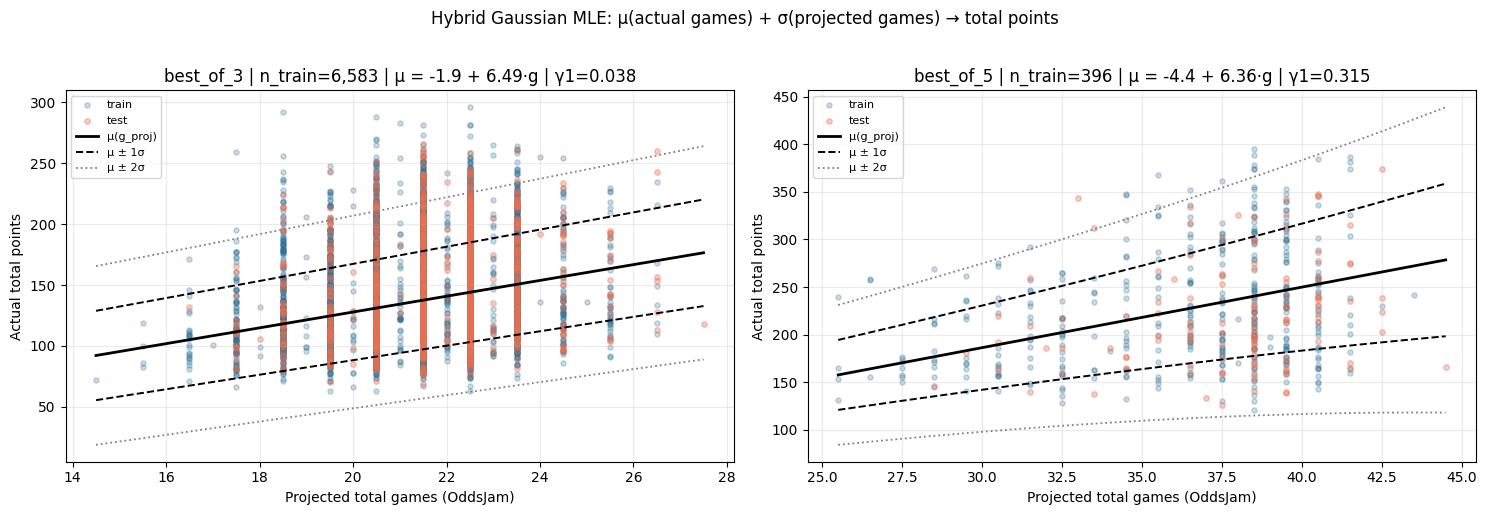

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
fig.suptitle(
    "Hybrid Gaussian MLE: μ(actual games) + σ(projected games) → total points",
    y=1.02,
)

for ax, bo in zip(axes, (3, 5)):
    fit = mle_by_segment.get(bo)
    tr = train_seg.get(bo, pd.DataFrame())
    te = test_seg.get(bo, pd.DataFrame())

    if fit is None or tr.empty:
        ax.set_title(f"best_of_{bo} | no fit")
        ax.grid(alpha=0.25)
        continue

    g_train = tr["projected_total_games"].to_numpy(dtype=float)
    y_train = tr["total_points"].to_numpy(dtype=float)

    g_min = float(np.min(g_train))
    g_max = float(np.max(g_train))
    if not te.empty:
        g_min = min(g_min, float(te["projected_total_games"].min()))
        g_max = max(g_max, float(te["projected_total_games"].max()))

    g_grid = np.linspace(g_min, g_max, 240)
    mu = fit.predict_mean(g_grid)
    sigma = fit.predict_sigma(g_grid)

    ax.scatter(g_train, y_train, s=14, alpha=0.25, color="#2a6f97", label="train")
    if not te.empty:
        ax.scatter(
            te["projected_total_games"],
            te["total_points"],
            s=16,
            alpha=0.35,
            color="#e76f51",
            label="test",
        )

    ax.plot(g_grid, mu, color="black", linewidth=2.0, label="μ(g_proj)")
    ax.plot(g_grid, mu + sigma, color="black", ls="--", lw=1.4, label="μ ± 1σ")
    ax.plot(g_grid, mu - sigma, color="black", ls="--", lw=1.4)
    ax.plot(g_grid, mu + 2 * sigma, color="gray", ls=":", lw=1.3, label="μ ± 2σ")
    ax.plot(g_grid, mu - 2 * sigma, color="gray", ls=":", lw=1.3)

    ax.set_title(
        f"best_of_{bo} | n_train={fit.n_obs:,} | "
        f"μ = {fit.intercept:.1f} + {fit.slope:.2f}·g | γ1={fit.gamma[1]:.3f}"
    )
    ax.set_xlabel("Projected total games (OddsJam)")
    ax.set_ylabel("Actual total points")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Quick read

Black $\mu(g_{\mathrm{proj}})$ is the actual-games mean evaluated at the consensus line. Wider $\sigma$ bands (vs fitting σ on actual games) reflect consensus miss plus points noise; $\gamma_1$ indexes heteroskedasticity in projected games.

## Calibration B + C (tournament holdout)

Fit hybrid MLE once on the **train** tournaments; score Calibration B/C on the **test** tournaments (post-cutoff only). No bootstrap resampling.

- **B**: empirical exceedance vs target p-more
- **C**: $P(\text{actual} > \mu)$ by quantile bins of predicted total points

Bo3: 10 bins; bo5: 8 bins.

best_of_3: n_train=6,583, n_test=1,425
best_of_5: n_train=396, n_test=124


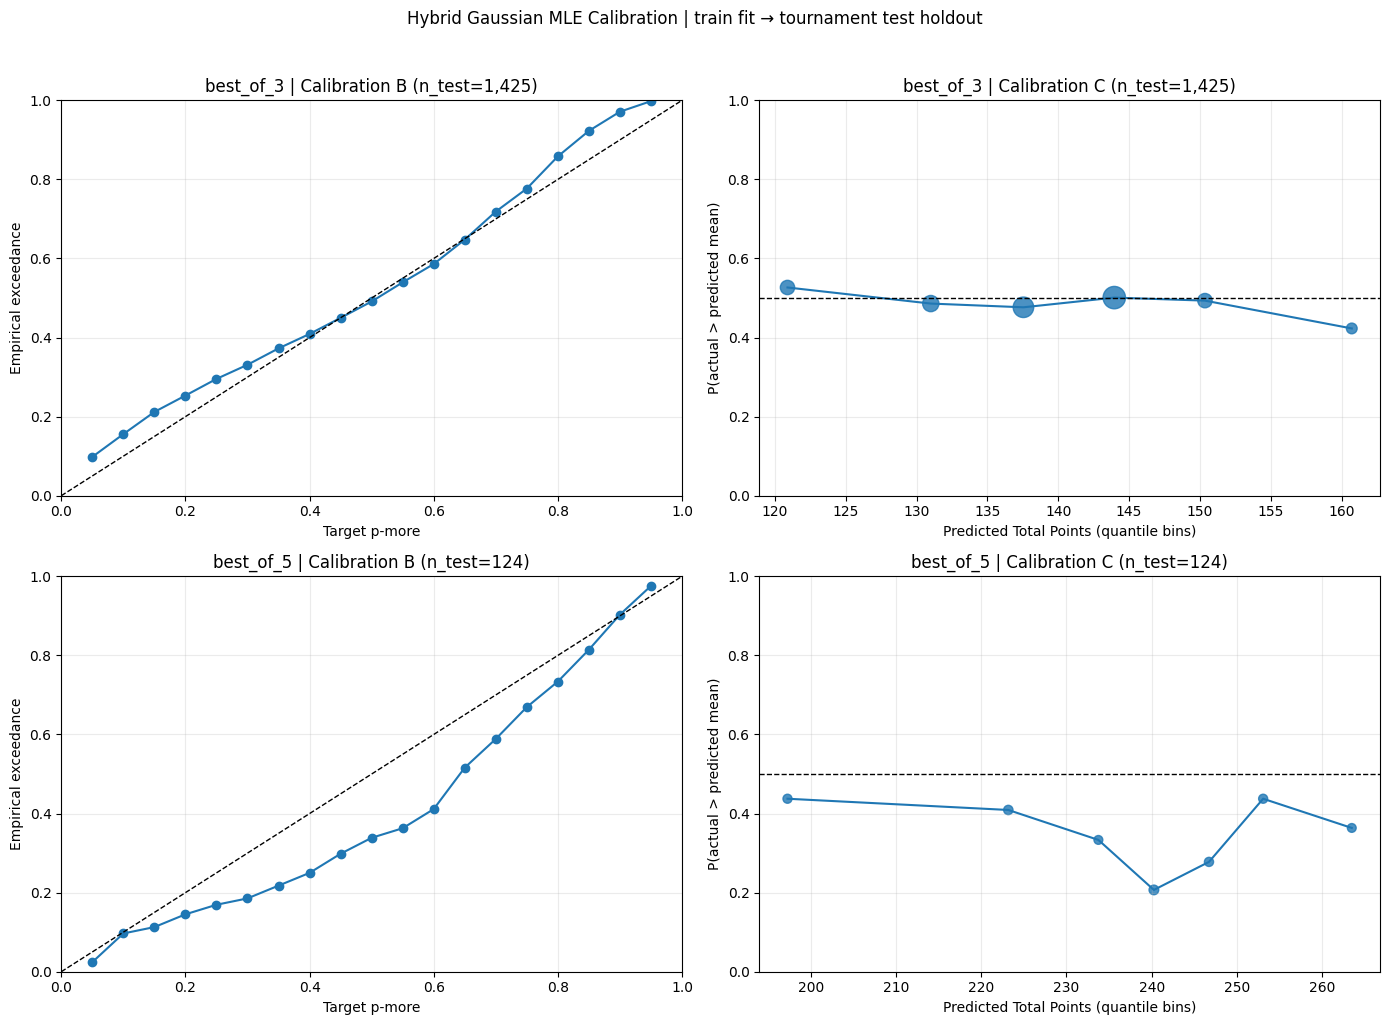

In [5]:
cal_payload: dict[str, dict] = {}
for segment_label, bo, n_bins in [("best_of_3", 3, 10), ("best_of_5", 5, 8)]:
    fit = mle_by_segment.get(bo)
    te = test_seg.get(bo)
    if fit is None:
        print(f"{segment_label}: no train fit; skipping calibration")
        continue
    if te is None or len(te) < 5:
        print(f"{segment_label}: insufficient test rows ({0 if te is None else len(te)}); skipping")
        continue

    cal_payload[segment_label] = score_games_only_mle_calibration(
        fit,
        te["projected_total_games"].to_numpy(),
        te["total_points"].to_numpy(),
        n_bins=n_bins,
        p_more_grid=P_MORE_GRID,
    )
    print(
        f"{segment_label}: n_train={cal_payload[segment_label]['n_train_fit']:,}, "
        f"n_test={cal_payload[segment_label]['n_test']:,}"
    )

if len(cal_payload) < 2:
    raise ValueError("Need both best_of_3 and best_of_5 calibration payloads to plot.")

# Shared marker-size scale for Calibration C across bo3 / bo5.
combined_counts = np.concatenate(
    [
        np.asarray(cal_payload["best_of_3"]["curve_c_count"], dtype=float),
        np.asarray(cal_payload["best_of_5"]["curve_c_count"], dtype=float),
    ]
)
valid_counts = combined_counts[np.isfinite(combined_counts) & (combined_counts > 0)]
min_count = float(np.min(valid_counts)) if len(valid_counts) else np.nan
max_count = float(np.max(valid_counts)) if len(valid_counts) else np.nan

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey="col")
fig.suptitle(
    "Hybrid Gaussian MLE Calibration | train fit → tournament test holdout",
    y=1.02,
)

for row_idx, segment_label in enumerate(["best_of_3", "best_of_5"]):
    res = cal_payload[segment_label]

    # Calibration B
    ax_b = axes[row_idx, 0]
    ax_b.plot(P_MORE_GRID, res["curve_b"], marker="o", linewidth=1.5)
    ax_b.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")
    ax_b.set_xlim(0.0, 1.0)
    ax_b.set_ylim(0.0, 1.0)
    ax_b.set_xlabel("Target p-more")
    ax_b.set_ylabel("Empirical exceedance")
    ax_b.set_title(f"{segment_label} | Calibration B (n_test={res['n_test']:,})")
    ax_b.grid(alpha=0.25)

    # Calibration C
    ax_c = axes[row_idx, 1]
    x = np.asarray(res["curve_c_x"], dtype=float)
    y_c = np.asarray(res["curve_c"], dtype=float)
    n_vals = np.asarray(res["curve_c_count"], dtype=float)

    if np.isfinite(min_count) and np.isfinite(max_count) and max_count > min_count:
        sizes = 40 + 220 * ((n_vals - min_count) / (max_count - min_count))
    else:
        sizes = np.full(len(x), 120.0)

    ax_c.plot(x, y_c, linewidth=1.5)
    ax_c.scatter(x, y_c, s=sizes, alpha=0.8)
    ax_c.axhline(0.5, linestyle="--", linewidth=1, color="black")
    ax_c.set_ylim(0.0, 1.0)
    ax_c.set_xlabel("Predicted Total Points (quantile bins)")
    ax_c.set_ylabel("P(actual > predicted mean)")
    ax_c.set_title(f"{segment_label} | Calibration C (n_test={res['n_test']:,})")
    ax_c.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## p-more 0.5 exceedance by category × competition level

Tournament **test** holdout only. Each row is `category_name | competition_level` (so Grand Slams split ATP vs WTA). Tick at 0.5 = fair mean; second tick = empirical $P(\text{actual} > \mu)$ using hybrid μ scored at OddsJam projected games. Labels show train/test tournament and match counts.

Panels (top → bottom):
1. Competition-level breakdown scored with the **bo3** fit (excludes ATP Grand Slam)
2. Men / Women aggregates for all **bo3** matches
3. **ATP | grand_slam** scored with the **bo5** fit

Orange diamond on each row: test-set rate that actual games exceed the OJ consensus games line.


,level_label,n_train_tournaments,n_train_matches,n_test_tournaments,n_test_matches,empirical_exceedance,n_test_scored,games_line_exceedance,n_games_line
0,WTA | wta_250,26,618,8,153,0.535948,153,0.496732,153
1,ATP | atp_1000,14,1408,2,206,0.524272,206,0.514563,206
2,ATP | atp_500,21,750,3,122,0.508197,122,0.508197,122
3,WTA | grand_slam,5,780,2,245,0.506122,245,0.461224,245
4,ATP | atp_250,34,1153,13,392,0.479592,392,0.487245,392
5,WTA | wta_1000,14,975,2,114,0.464912,114,0.447368,114
6,WTA | wta_500,20,510,7,97,0.443299,97,0.412371,97
7,ATP | grand_slam,5,785,2,220,0.372727,220,0.354545,220


,level_label,n_train_tournaments,n_train_matches,n_test_tournaments,n_test_matches,empirical_exceedance,n_test_scored,games_line_exceedance,n_games_line
0,Women | best_of_3,65,2883,19,609,0.495895,609,0.459770,609
1,Men | best_of_3,74,3700,20,816,0.487745,816,0.485294,816


/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_77210/890784157.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


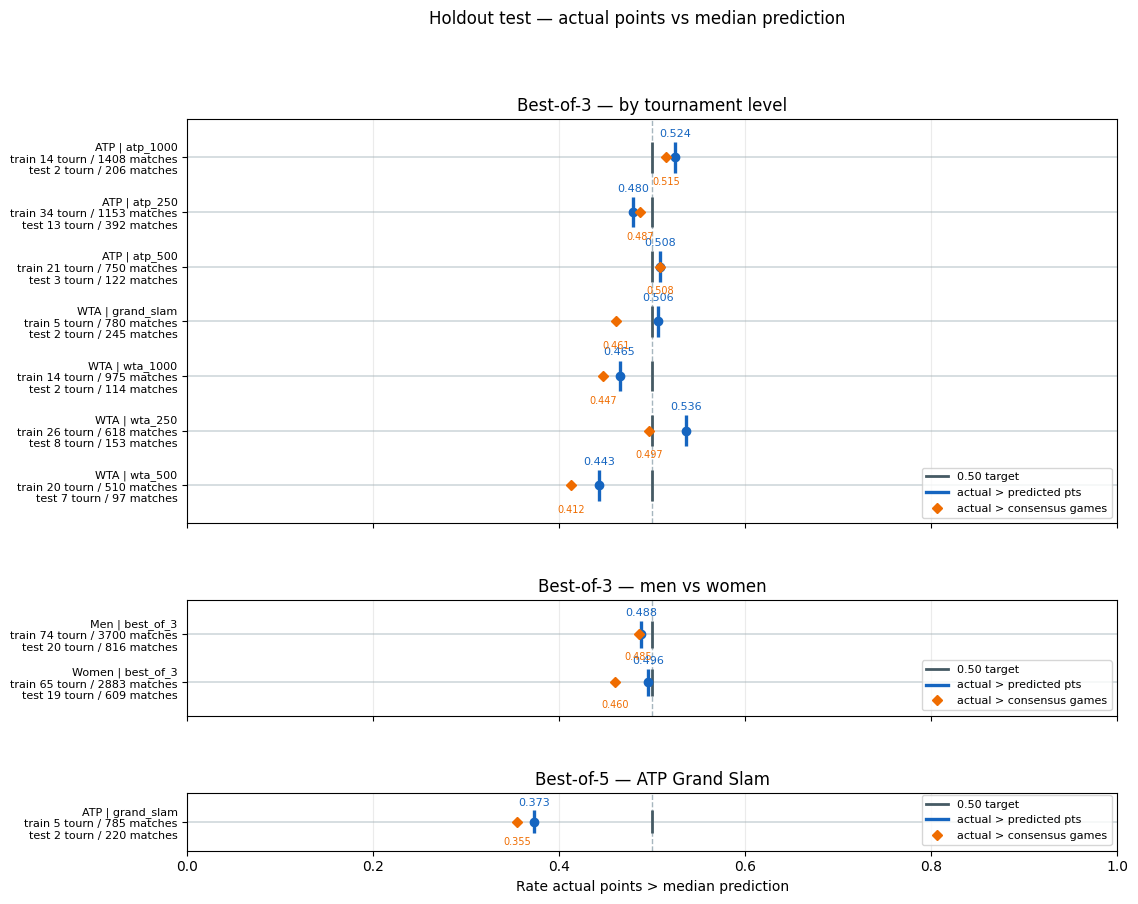

No empty levels: every train category × competition_level has scorable test matches.


In [6]:
level_summary, empty_level_msgs = evaluate_pmore_half_by_level(
    train_df,
    test_df,
    mle_by_segment,
)

plot_df = level_summary.loc[level_summary["n_test_scored"] > 0].copy()
if plot_df.empty:
    raise ValueError("No scorable test rows by category × competition_level.")

ATP_GS_LABEL = "ATP | grand_slam"
bo5_df = plot_df.loc[plot_df["level_label"] == ATP_GS_LABEL].copy()
bo3_df = plot_df.loc[plot_df["level_label"] != ATP_GS_LABEL].copy()
bo3_df = bo3_df.sort_values("level_label", ascending=False).reset_index(drop=True)
bo5_df = bo5_df.sort_values("level_label", ascending=False).reset_index(drop=True)

if 3 not in mle_by_segment:
    raise ValueError("Missing bo3 fit in mle_by_segment; cannot build gender aggregates.")
gender_df = evaluate_pmore_half_by_gender_bo3(
    train_df,
    test_df,
    mle_by_segment[3],
)
gender_df = gender_df.loc[gender_df["n_test_scored"] > 0].copy()
# DataFrame order is bottom→top on the axis; put Women first so Men renders above.
gender_df = gender_df.sort_values("level_label", ascending=False).reset_index(drop=True)

display(plot_df)
display(gender_df)


def _draw_level_exceedance(ax: plt.Axes, df: pd.DataFrame, *, title: str, show_xlabel: bool) -> None:
    if df.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, "No rows", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    y_pos = np.arange(len(df))
    has_games_line = "games_line_exceedance" in df.columns
    for i, (_, row) in enumerate(df.iterrows()):
        y = float(y_pos[i])
        ax.hlines(y, 0.0, 1.0, color="#cfd8dc", linewidth=1.2, zorder=1)
        ax.vlines(0.5, y - 0.28, y + 0.28, color="#455a64", linewidth=2.0, zorder=3)
        x = float(row["empirical_exceedance"])
        ax.vlines(x, y - 0.28, y + 0.28, color="#1565c0", linewidth=2.4, zorder=4)
        ax.plot(x, y, "o", color="#1565c0", markersize=6, zorder=5)
        ax.text(
            x,
            y + 0.34,
            f"{x:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#1565c0",
        )
        if has_games_line and np.isfinite(row["games_line_exceedance"]):
            gx = float(row["games_line_exceedance"])
            ax.plot(gx, y, "D", color="#ef6c00", markersize=5.5, zorder=6)
            ax.text(
                gx,
                y - 0.36,
                f"{gx:.3f}",
                ha="center",
                va="top",
                fontsize=7,
                color="#ef6c00",
            )

    ax.axvline(0.5, color="#90a4ae", linestyle="--", linewidth=1.0, alpha=0.8, zorder=0)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.7, len(df) - 0.3)
    ax.set_yticks(y_pos)
    y_labels = [
        (
            f"{row['level_label']}\n"
            f"train {int(row['n_train_tournaments'])} tourn / {int(row['n_train_matches'])} matches\n"
            f"test {int(row['n_test_tournaments'])} tourn / {int(row['n_test_matches'])} matches"
        )
        for _, row in df.iterrows()
    ]
    ax.set_yticklabels(y_labels, fontsize=8)
    if show_xlabel:
        ax.set_xlabel("Rate actual points > median prediction")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    ax.plot([], [], color="#455a64", linewidth=2.0, label="0.50 target")
    ax.plot([], [], color="#1565c0", linewidth=2.4, label="actual > predicted pts")
    if has_games_line:
        ax.plot([], [], "D", color="#ef6c00", markersize=5.5, label="actual > consensus games")
    ax.legend(loc="lower right", fontsize=8)

n_bo3 = max(len(bo3_df), 1)
n_gender = max(len(gender_df), 1)
n_bo5 = max(len(bo5_df), 1)
fig_h = 0.55 * (n_bo3 + n_gender + n_bo5) + 4.0
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, fig_h),
    sharex=True,
    gridspec_kw={
        "height_ratios": [n_bo3, max(n_gender, 0.9), max(n_bo5, 0.8)],
        "hspace": 0.40,
    },
)
fig.suptitle("Holdout test — actual points vs median prediction", y=0.995)

_draw_level_exceedance(
    axes[0],
    bo3_df,
    title="Best-of-3 — by tournament level",
    show_xlabel=False,
)
_draw_level_exceedance(
    axes[1],
    gender_df,
    title="Best-of-3 — men vs women",
    show_xlabel=False,
)
_draw_level_exceedance(
    axes[2],
    bo5_df,
    title="Best-of-5 — ATP Grand Slam",
    show_xlabel=True,
)

plt.tight_layout()
plt.show()

if empty_level_msgs:
    print("Empty / unscored levels (no test exceedance):")
    for msg in empty_level_msgs:
        print(f"  - {msg}")
else:
    print("No empty levels: every train category × competition_level has scorable test matches.")


## Holdout test — separate men / women models

Same tournament train/test split as above, but fit **three** hybrid models on train:

- men + best-of-3
- men + best-of-5
- women + best-of-3

Score the holdout test set with the matching model. Plot layout matches the men/women bootstrap section (levels split by which bo3 model applies).

Train fits: ['men_bo3', 'men_bo5', 'women_bo3']


,level_label,n_train_tournaments,n_train_matches,n_test_tournaments,n_test_matches,empirical_exceedance,n_test_scored,games_line_exceedance,n_games_line
5,ATP | atp_500,21,750,3,122,0.516393,122,0.508197,122
6,ATP | atp_250,34,1153,13,392,0.500000,392,0.487245,392
7,ATP | atp_1000,14,1408,2,206,0.543689,206,0.514563,206


,level_label,n_train_tournaments,n_train_matches,n_test_tournaments,n_test_matches,empirical_exceedance,n_test_scored,games_line_exceedance,n_games_line
0,WTA | wta_500,20,510,7,97,0.381443,97,0.412371,97
1,WTA | wta_250,26,618,8,153,0.503268,153,0.496732,153
2,WTA | wta_1000,14,975,2,114,0.438596,114,0.447368,114
3,WTA | grand_slam,5,780,2,245,0.485714,245,0.461224,245


,level_label,n_train_tournaments,n_train_matches,n_test_tournaments,n_test_matches,empirical_exceedance,n_test_scored,games_line_exceedance,n_games_line
0,Women | best_of_3,65,2883,19,609,0.464696,609,0.459770,609
1,Men | best_of_3,74,3700,20,816,0.504902,816,0.485294,816


,level_label,n_train_tournaments,n_train_matches,n_test_tournaments,n_test_matches,empirical_exceedance,n_test_scored,games_line_exceedance,n_games_line
0,ATP | grand_slam,5,785,2,220,0.33871,124,0.354545,220


/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_77210/1803912439.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


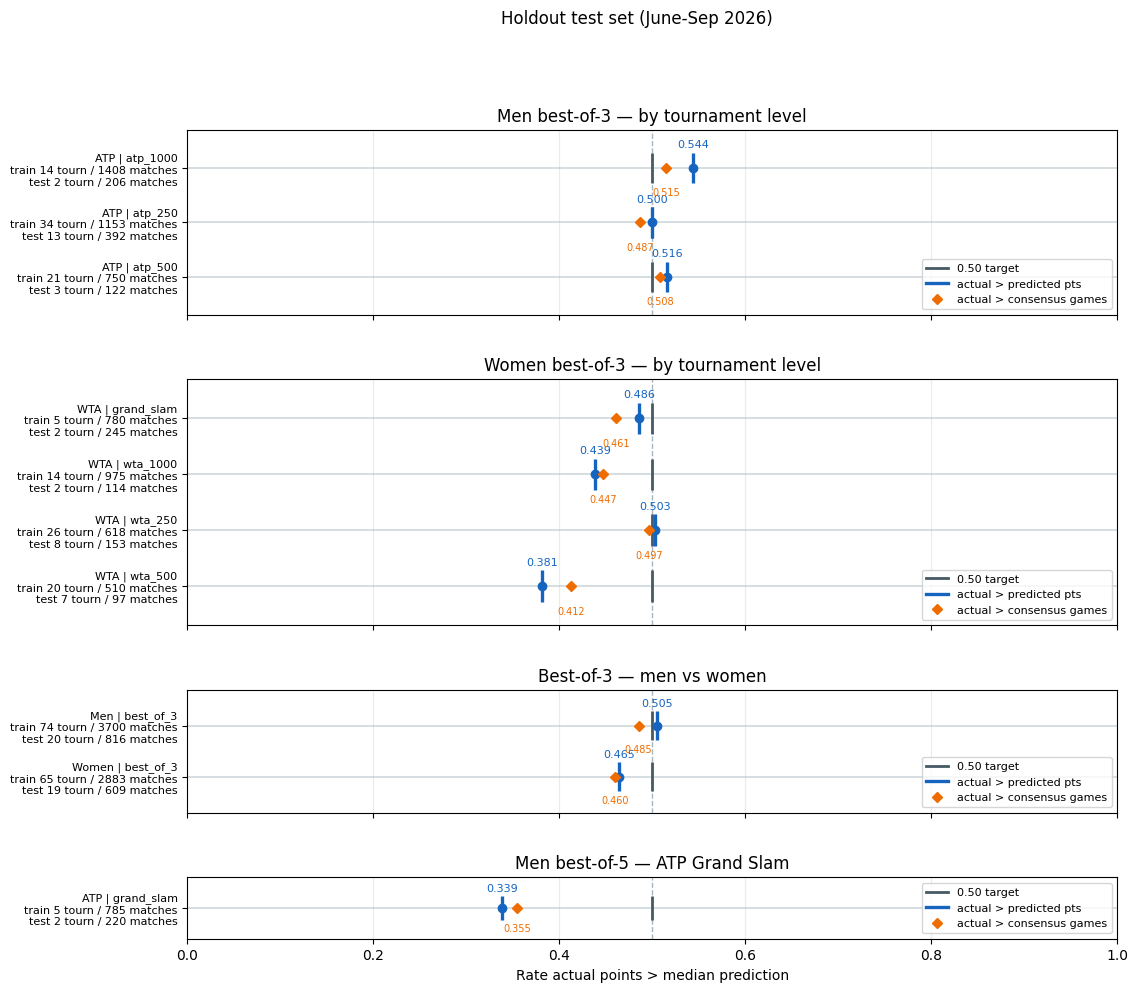

In [7]:
if "_draw_level_exceedance" not in globals():
    raise ValueError("Run the previous holdout plot cell first (defines _draw_level_exceedance).")

holdout_sex = evaluate_holdout_pmore_half_by_gender(train_df, test_df)
print("Train fits:", holdout_sex["fit_keys"])

h_level = holdout_sex["level_summary"].loc[
    holdout_sex["level_summary"]["n_test_scored"] > 0
].copy()
h_sex = holdout_sex["sex_summary"].loc[
    holdout_sex["sex_summary"]["n_test_scored"] > 0
].copy()
h_gs = holdout_sex["atp_gs_summary"].loc[
    holdout_sex["atp_gs_summary"]["n_test_scored"] > 0
].copy()

men_holdout_df = h_level.loc[
    h_level["level_label"].astype(str).str.startswith("ATP |")
    & (h_level["level_label"] != "ATP | grand_slam")
].copy()
women_holdout_df = h_level.loc[
    h_level["level_label"].astype(str).str.startswith("WTA |")
].copy()
# Women first in DF so Men renders above on the men/women panel.
h_sex = h_sex.sort_values("level_label", ascending=False).reset_index(drop=True)

display(men_holdout_df)
display(women_holdout_df)
display(h_sex)
display(h_gs)

n_men = max(len(men_holdout_df), 1)
n_women = max(len(women_holdout_df), 1)
n_sex = max(len(h_sex), 1)
n_gs = max(len(h_gs), 1)
fig_h = 0.55 * (n_men + n_women + n_sex + n_gs) + 5.0
fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, fig_h),
    sharex=True,
    gridspec_kw={
        "height_ratios": [n_men, n_women, max(n_sex, 0.9), max(n_gs, 0.8)],
        "hspace": 0.42,
    },
)
fig.suptitle("Holdout test set (June-Sep 2026)", y=0.995)

_draw_level_exceedance(
    axes[0],
    men_holdout_df,
    title="Men best-of-3 — by tournament level",
    show_xlabel=False,
)
_draw_level_exceedance(
    axes[1],
    women_holdout_df,
    title="Women best-of-3 — by tournament level",
    show_xlabel=False,
)
_draw_level_exceedance(
    axes[2],
    h_sex,
    title="Best-of-3 — men vs women",
    show_xlabel=False,
)
_draw_level_exceedance(
    axes[3],
    h_gs,
    title="Men best-of-5 — ATP Grand Slam",
    show_xlabel=True,
)

plt.tight_layout()
plt.show()

## Bootstrap p-more 0.5 (stratified 70/30, full dataset)

Alternative to the tournament-time holdout above (left unchanged).

- Pool **all** filtered matches (`filtered_df`)
- Each of 200 repeats: within every `category × competition_level`, sample 30% test / 70% train, then pool
- Fit hybrid **bo3 / bo5** on that train fold; score test at projected games
- Plot mean empirical exceedance at p-more 0.5 with p10–p90 shaded band

Same three panels: competition-level (bo3) → men/women bo3 → ATP Grand Slam (bo5).

Orange diamond: full-dataset rate that actual games exceed the OJ consensus games line (not bootstrapped).


Bootstrap used 200/200 repeats on n_obs=8,528 (test_size=0.3)


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,WTA | wta_500,0.472445,0.434066,0.516484,200,425.0,182.0,27,607,0.434926,607
1,WTA | wta_250,0.540563,0.506061,0.571429,200,540.0,231.0,34,771,0.466926,771
2,WTA | wta_1000,0.535183,0.504587,0.566055,200,762.0,327.0,16,1089,0.487603,1089
3,WTA | grand_slam,0.523117,0.493182,0.551948,200,717.0,308.0,7,1025,0.467317,1025
4,ATP | atp_500,0.461183,0.431298,0.492748,200,610.0,262.0,24,872,0.462156,872
5,ATP | atp_250,0.485043,0.461207,0.508836,200,1081.0,464.0,47,1545,0.485437,1545
6,ATP | atp_1000,0.489483,0.464669,0.514463,200,1130.0,484.0,16,1614,0.480793,1614


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,Women | best_of_3,0.521927,0.504676,0.538263,200,2444.000,1048.000,84,3492,0.467927,3492
1,Men | best_of_3,0.479174,0.464959,0.494870,200,3160.405,1355.595,94,4516,0.474978,4516


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,ATP | grand_slam,0.420124,0.378535,0.462267,200,703.0,156.405,7,1005,0.429851,1005


/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_77210/399285993.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


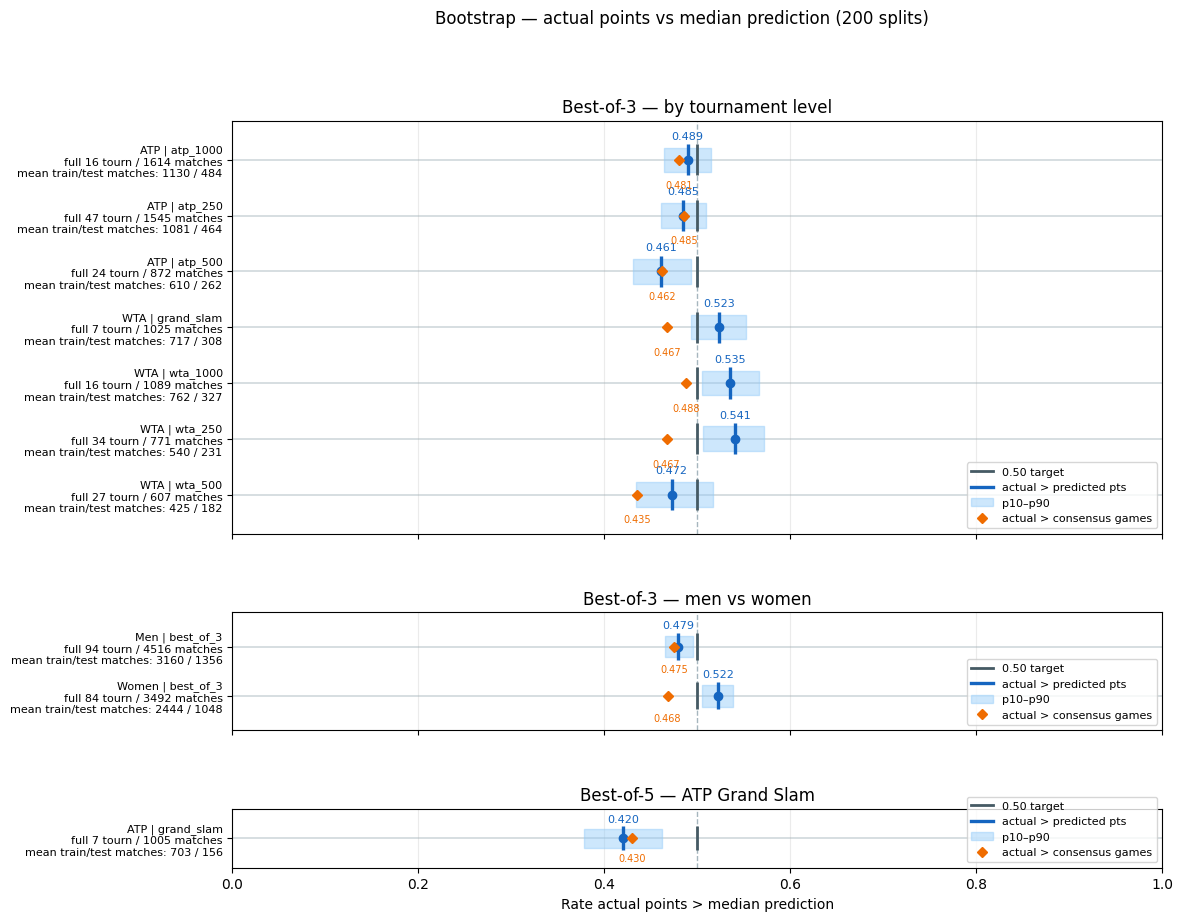

In [8]:
N_REPEATS_BOOT_LEVEL = 200
TEST_SIZE_BOOT_LEVEL = 0.30

boot_base = data["filtered_df"].copy()
boot_panels = bootstrap_pmore_half_panels(
    boot_base,
    n_repeats=N_REPEATS_BOOT_LEVEL,
    test_size=TEST_SIZE_BOOT_LEVEL,
)

boot_level_df = boot_panels["level_summary"].loc[
    np.isfinite(boot_panels["level_summary"]["exceedance_mean"])
].copy()
boot_gender_df = boot_panels["gender_summary"].loc[
    np.isfinite(boot_panels["gender_summary"]["exceedance_mean"])
].copy()
boot_gs_df = boot_panels["atp_gs_summary"].loc[
    np.isfinite(boot_panels["atp_gs_summary"]["exceedance_mean"])
].copy()

print(
    f"Bootstrap used {boot_panels['n_boot_used']}/{boot_panels['n_repeats']} repeats "
    f"on n_obs={boot_panels['n_obs']:,} (test_size={boot_panels['test_size']})"
)
display(boot_level_df)
display(boot_gender_df)
display(boot_gs_df)


def _draw_bootstrap_exceedance(
    ax: plt.Axes,
    df: pd.DataFrame,
    *,
    title: str,
    show_xlabel: bool,
) -> None:
    if df.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, "No rows", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    y_pos = np.arange(len(df))
    has_games_line = "games_line_exceedance" in df.columns
    for i, (_, row) in enumerate(df.iterrows()):
        y = float(y_pos[i])
        ax.hlines(y, 0.0, 1.0, color="#cfd8dc", linewidth=1.2, zorder=1)
        p10 = float(row["exceedance_p10"])
        p90 = float(row["exceedance_p90"])
        mean_x = float(row["exceedance_mean"])
        ax.fill_betweenx([y - 0.22, y + 0.22], p10, p90, color="#90caf9", alpha=0.45, zorder=2)
        ax.vlines(0.5, y - 0.28, y + 0.28, color="#455a64", linewidth=2.0, zorder=3)
        ax.vlines(mean_x, y - 0.28, y + 0.28, color="#1565c0", linewidth=2.4, zorder=4)
        ax.plot(mean_x, y, "o", color="#1565c0", markersize=6, zorder=5)
        ax.text(
            mean_x,
            y + 0.34,
            f"{mean_x:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#1565c0",
        )
        if has_games_line and np.isfinite(row["games_line_exceedance"]):
            gx = float(row["games_line_exceedance"])
            ax.plot(gx, y, "D", color="#ef6c00", markersize=5.5, zorder=6)
            ax.text(
                gx,
                y - 0.36,
                f"{gx:.3f}",
                ha="center",
                va="top",
                fontsize=7,
                color="#ef6c00",
            )

    ax.axvline(0.5, color="#90a4ae", linestyle="--", linewidth=1.0, alpha=0.8, zorder=0)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.7, len(df) - 0.3)
    ax.set_yticks(y_pos)
    y_labels = [
        (
            f"{row['level_label']}\n"
            f"full {int(row['n_full_tournaments'])} tourn / {int(row['n_full_matches'])} matches\n"
            f"mean train/test matches: {row['mean_n_train_matches']:.0f} / {row['mean_n_test_matches']:.0f}"
        )
        for _, row in df.iterrows()
    ]
    ax.set_yticklabels(y_labels, fontsize=8)
    if show_xlabel:
        ax.set_xlabel("Rate actual points > median prediction")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    ax.plot([], [], color="#455a64", linewidth=2.0, label="0.50 target")
    ax.plot([], [], color="#1565c0", linewidth=2.4, label="actual > predicted pts")
    ax.fill_between([], [], [], color="#90caf9", alpha=0.45, label="p10–p90")
    if has_games_line:
        ax.plot([], [], "D", color="#ef6c00", markersize=5.5, label="actual > consensus games")
    ax.legend(loc="lower right", fontsize=8)

n1 = max(len(boot_level_df), 1)
n2 = max(len(boot_gender_df), 1)
n3 = max(len(boot_gs_df), 1)
fig_h = 0.55 * (n1 + n2 + n3) + 4.2
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, fig_h),
    sharex=True,
    gridspec_kw={"height_ratios": [n1, max(n2, 0.9), max(n3, 0.8)], "hspace": 0.40},
)
fig.suptitle(
    f"Bootstrap — actual points vs median prediction ({boot_panels['n_boot_used']} splits)",
    y=0.995,
)

_draw_bootstrap_exceedance(
    axes[0],
    boot_level_df,
    title="Best-of-3 — by tournament level",
    show_xlabel=False,
)
_draw_bootstrap_exceedance(
    axes[1],
    boot_gender_df,
    title="Best-of-3 — men vs women",
    show_xlabel=False,
)
_draw_bootstrap_exceedance(
    axes[2],
    boot_gs_df,
    title="Best-of-5 — ATP Grand Slam",
    show_xlabel=True,
)

plt.tight_layout()
plt.show()


## Bootstrap p-more 0.5 with separate men / women models

Same stratified 70/30 bootstrap as above, but fits **three** hybrid models each repeat:

- men + bo3
- men + bo5
- women + bo3

Scoring uses the matching (men/women, best_of) model. Competition-level charts are split by which bo3 model applies (men vs women). Prior bootstrap / holdout sections are unchanged.

Men/women-segment bootstrap used 200/200 repeats on n_obs=8,528
Fit availability across repeats: {'men_bo3': 200, 'men_bo5': 200, 'women_bo3': 200}


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
4,ATP | atp_500,0.480057,0.450382,0.508015,200,610.0,262.0,24,872,0.462156,872
5,ATP | atp_250,0.506433,0.480388,0.530388,200,1081.0,464.0,47,1545,0.485437,1545
6,ATP | atp_1000,0.507552,0.483471,0.533058,200,1130.0,484.0,16,1614,0.480793,1614


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,WTA | wta_500,0.423956,0.384066,0.461538,200,425.0,182.0,27,607,0.434926,607
1,WTA | wta_250,0.501364,0.458874,0.537229,200,540.0,231.0,34,771,0.466926,771
2,WTA | wta_1000,0.506284,0.477064,0.532416,200,762.0,327.0,16,1089,0.487603,1089
3,WTA | grand_slam,0.496737,0.467532,0.529221,200,717.0,308.0,7,1025,0.467317,1025


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,Women | best_of_3,0.488096,0.471374,0.505725,200,2444.00,1048.00,84,3492,0.467927,3492
1,Men | best_of_3,0.499496,0.486968,0.513774,200,3160.44,1355.56,94,4516,0.474978,4516


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,ATP | grand_slam,0.417344,0.378564,0.455178,200,703.0,156.44,7,1005,0.429851,1005


/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_77210/3149425356.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


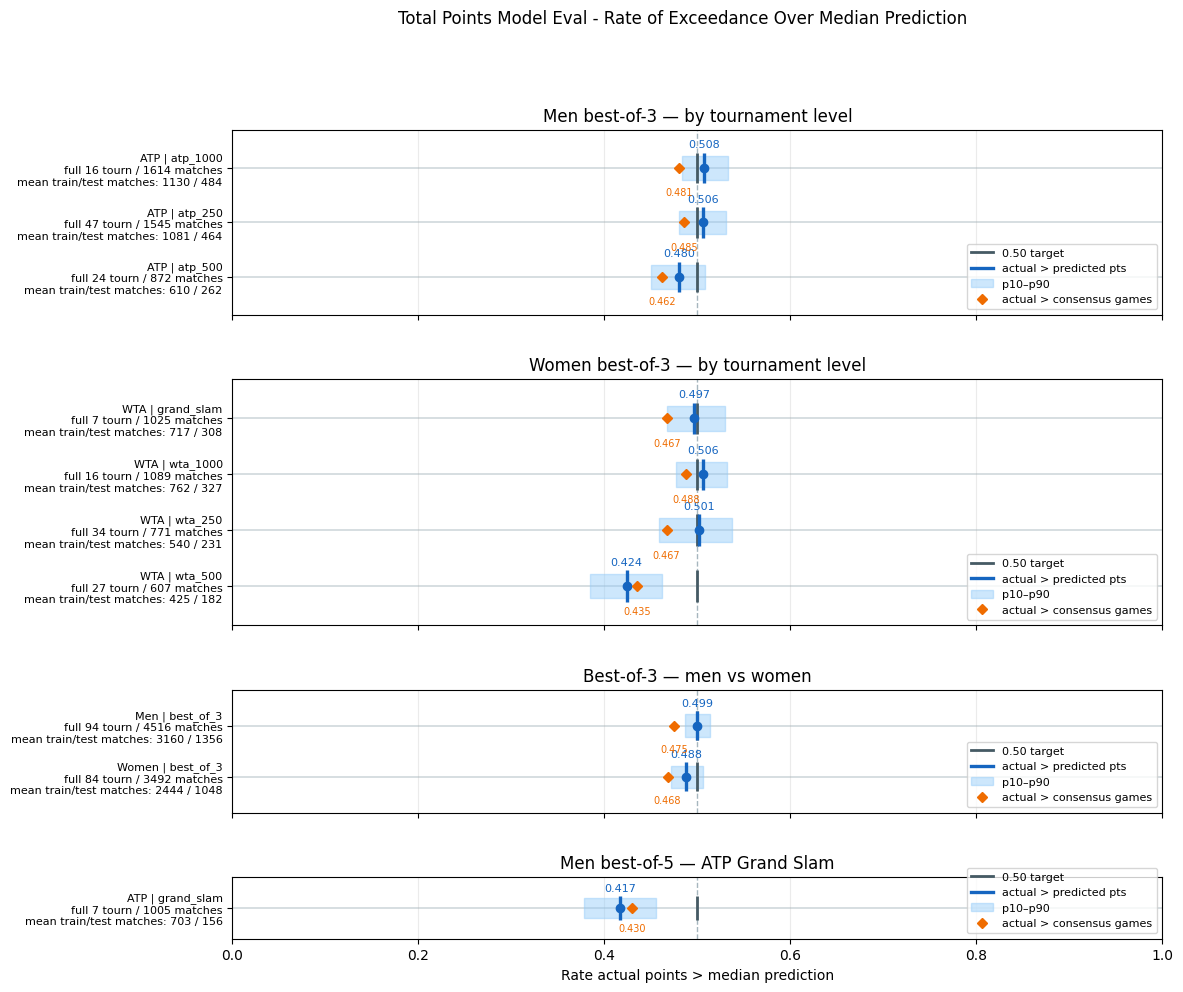

In [9]:
if "_draw_bootstrap_exceedance" not in globals():
    raise ValueError("Run the previous bootstrap plot cell first (defines _draw_bootstrap_exceedance).")

N_REPEATS_BOOT_SEX = 200
TEST_SIZE_BOOT_SEX = 0.30

sex_boot_panels = bootstrap_pmore_half_panels_by_gender(
    data["filtered_df"].copy(),
    n_repeats=N_REPEATS_BOOT_SEX,
    test_size=TEST_SIZE_BOOT_SEX,
)

g_level_df = sex_boot_panels["level_summary"].loc[
    np.isfinite(sex_boot_panels["level_summary"]["exceedance_mean"])
].copy()
g_sex_df = sex_boot_panels["gender_summary"].loc[
    np.isfinite(sex_boot_panels["gender_summary"]["exceedance_mean"])
].copy()
g_gs_df = sex_boot_panels["atp_gs_summary"].loc[
    np.isfinite(sex_boot_panels["atp_gs_summary"]["exceedance_mean"])
].copy()

# Split competition-level rows by which bo3 model scores them.
men_level_df = g_level_df.loc[
    g_level_df["level_label"].astype(str).str.startswith("ATP |")
].copy()
women_level_df = g_level_df.loc[
    g_level_df["level_label"].astype(str).str.startswith("WTA |")
].copy()

print(
    f"Men/women-segment bootstrap used {sex_boot_panels['n_boot_used']}/"
    f"{sex_boot_panels['n_repeats']} repeats on n_obs={sex_boot_panels['n_obs']:,}"
)
print("Fit availability across repeats:", sex_boot_panels.get("fit_key_counts"))
display(men_level_df)
display(women_level_df)
display(g_sex_df)
display(g_gs_df)

n_men = max(len(men_level_df), 1)
n_women = max(len(women_level_df), 1)
n_sex = max(len(g_sex_df), 1)
n_gs = max(len(g_gs_df), 1)
fig_h = 0.55 * (n_men + n_women + n_sex + n_gs) + 5.0
fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, fig_h),
    sharex=True,
    gridspec_kw={
        "height_ratios": [n_men, n_women, max(n_sex, 0.9), max(n_gs, 0.8)],
        "hspace": 0.42,
    },
)
fig.suptitle(
    f"Total Points Model Eval - Rate of Exceedance Over Median Prediction",
    y=0.995,
)

_draw_bootstrap_exceedance(
    axes[0],
    men_level_df,
    title="Men best-of-3 — by tournament level",
    show_xlabel=False,
)
_draw_bootstrap_exceedance(
    axes[1],
    women_level_df,
    title="Women best-of-3 — by tournament level",
    show_xlabel=False,
)
_draw_bootstrap_exceedance(
    axes[2],
    g_sex_df,
    title="Best-of-3 — men vs women",
    show_xlabel=False,
)
_draw_bootstrap_exceedance(
    axes[3],
    g_gs_df,
    title="Men best-of-5 — ATP Grand Slam",
    show_xlabel=True,
)

plt.tight_layout()
plt.show()

## Bootstrap p-more 0.5 with per-tournament-level models

Same stratified 70/30 bootstrap, but fits a **separate hybrid model for each** category × competition level each repeat (e.g. ATP 250, WTA 500, ATP Grand Slam, …).

Test matches are scored with their level’s own model. Men vs women aggregates pool best-of-3 matches after level-specific scoring. Prior sections are unchanged.

Per-level-model bootstrap used 200/200 repeats on n_obs=8,528
Fit availability across repeats: {'ATP | atp_250': 200, 'ATP | atp_500': 200, 'ATP | grand_slam': 200, 'ATP | atp_1000': 200, 'WTA | wta_250': 200, 'WTA | grand_slam': 200, 'WTA | wta_1000': 200, 'WTA | wta_500': 200}


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
4,ATP | atp_500,0.487615,0.453817,0.526718,200,610.0,262.0,24,872,0.462156,872
5,ATP | atp_250,0.506649,0.478448,0.536853,200,1081.0,464.0,47,1545,0.485437,1545
6,ATP | atp_1000,0.510196,0.485537,0.537190,200,1130.0,484.0,16,1614,0.480793,1614


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,WTA | wta_500,0.440907,0.401099,0.478571,200,425.0,182.0,27,607,0.434926,607
1,WTA | wta_250,0.493939,0.463203,0.528139,200,540.0,231.0,34,771,0.466926,771
2,WTA | wta_1000,0.507156,0.480122,0.538226,200,762.0,327.0,16,1089,0.487603,1089
3,WTA | grand_slam,0.490974,0.454545,0.525974,200,717.0,308.0,7,1025,0.467317,1025


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,Women | best_of_3,0.487982,0.472233,0.505821,200,2444.000,1048.000,84,3492,0.467927,3492
1,Men | best_of_3,0.500801,0.484428,0.517397,200,3160.245,1355.755,94,4516,0.474978,4516


,level_label,exceedance_mean,exceedance_p10,exceedance_p90,n_boot,mean_n_train_matches,mean_n_test_matches,n_full_tournaments,n_full_matches,games_line_exceedance,n_games_line
0,ATP | grand_slam,0.439371,0.403974,0.470199,200,703.0,302.0,7,1005,0.429851,1005


/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_77210/957571772.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


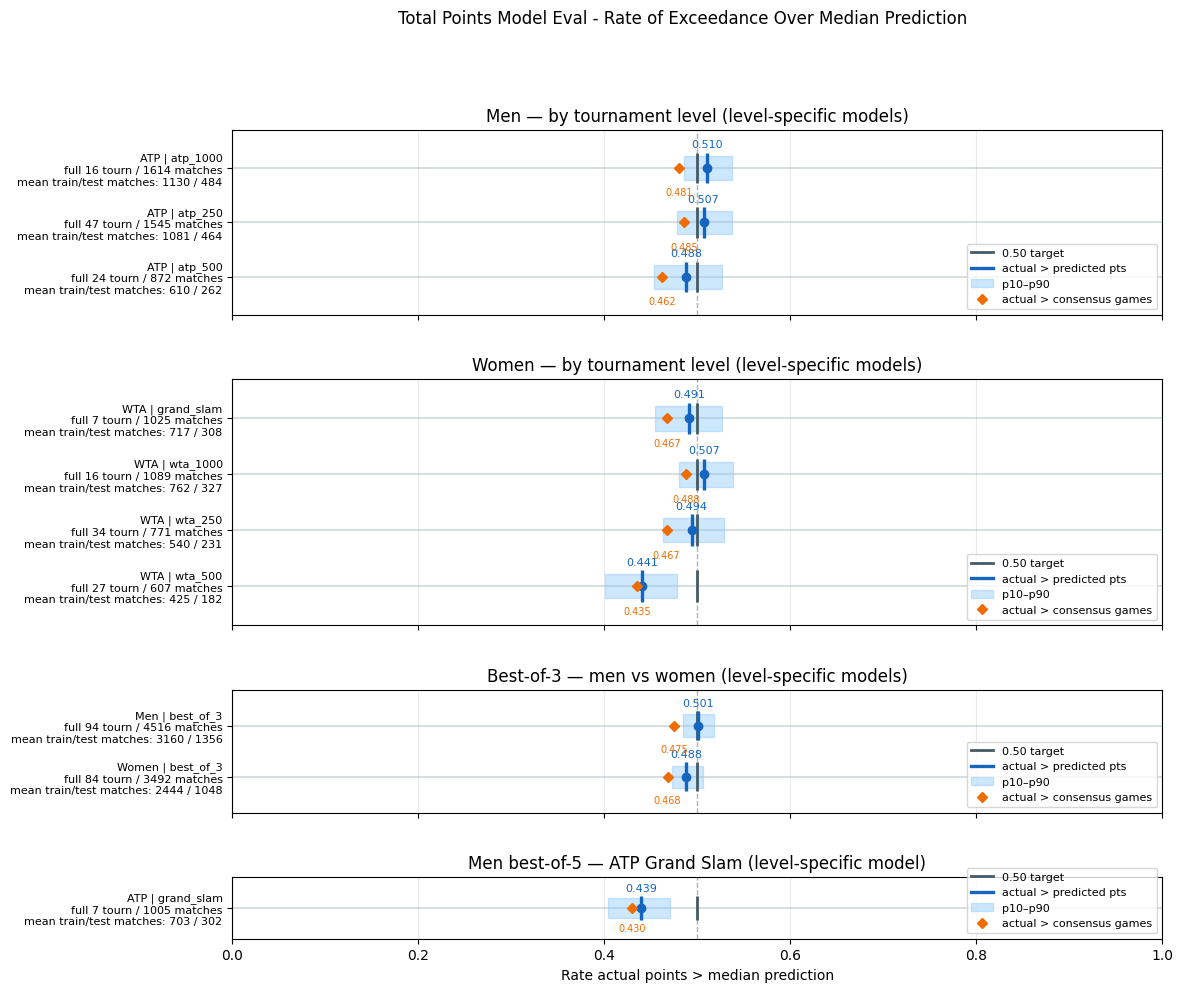

In [10]:
if "_draw_bootstrap_exceedance" not in globals():
    raise ValueError("Run the previous bootstrap plot cell first (defines _draw_bootstrap_exceedance).")

N_REPEATS_BOOT_LEVEL_MODEL = 200
TEST_SIZE_BOOT_LEVEL_MODEL = 0.30

level_model_boot = bootstrap_pmore_half_panels_by_tournament_level(
    data["filtered_df"].copy(),
    n_repeats=N_REPEATS_BOOT_LEVEL_MODEL,
    test_size=TEST_SIZE_BOOT_LEVEL_MODEL,
)

lm_level_df = level_model_boot["level_summary"].loc[
    np.isfinite(level_model_boot["level_summary"]["exceedance_mean"])
].copy()
lm_sex_df = level_model_boot["gender_summary"].loc[
    np.isfinite(level_model_boot["gender_summary"]["exceedance_mean"])
].copy()
lm_gs_df = level_model_boot["atp_gs_summary"].loc[
    np.isfinite(level_model_boot["atp_gs_summary"]["exceedance_mean"])
].copy()

men_lm_df = lm_level_df.loc[
    lm_level_df["level_label"].astype(str).str.startswith("ATP |")
].copy()
women_lm_df = lm_level_df.loc[
    lm_level_df["level_label"].astype(str).str.startswith("WTA |")
].copy()

print(
    f"Per-level-model bootstrap used {level_model_boot['n_boot_used']}/"
    f"{level_model_boot['n_repeats']} repeats on n_obs={level_model_boot['n_obs']:,}"
)
print("Fit availability across repeats:", level_model_boot.get("fit_key_counts"))
display(men_lm_df)
display(women_lm_df)
display(lm_sex_df)
display(lm_gs_df)

n_men = max(len(men_lm_df), 1)
n_women = max(len(women_lm_df), 1)
n_sex = max(len(lm_sex_df), 1)
n_gs = max(len(lm_gs_df), 1)
fig_h = 0.55 * (n_men + n_women + n_sex + n_gs) + 5.0
fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, fig_h),
    sharex=True,
    gridspec_kw={
        "height_ratios": [n_men, n_women, max(n_sex, 0.9), max(n_gs, 0.8)],
        "hspace": 0.42,
    },
)
fig.suptitle(
    "Total Points Model Eval - Rate of Exceedance Over Median Prediction",
    y=0.995,
)

_draw_bootstrap_exceedance(
    axes[0],
    men_lm_df,
    title="Men — by tournament level (level-specific models)",
    show_xlabel=False,
)
_draw_bootstrap_exceedance(
    axes[1],
    women_lm_df,
    title="Women — by tournament level (level-specific models)",
    show_xlabel=False,
)
_draw_bootstrap_exceedance(
    axes[2],
    lm_sex_df,
    title="Best-of-3 — men vs women (level-specific models)",
    show_xlabel=False,
)
_draw_bootstrap_exceedance(
    axes[3],
    lm_gs_df,
    title="Men best-of-5 — ATP Grand Slam (level-specific model)",
    show_xlabel=True,
)

plt.tight_layout()
plt.show()

## Actual vs predicted points by tournament (men/women models)

Fit hybrid models on **train** for:

- men + best-of-3
- women + best-of-3
- men + best-of-5

Score the tournament **test** holdout, then scatter actual total points vs predicted μ for each test tournament (one panel per `season_name`). The diagonal is perfect calibration.


Fits: ['men_bo3', 'men_bo5', 'women_bo3']
Scorable test matches: 1,549


,model_segment,season_id,season_name,n,mean_actual,mean_pred,mean_bias
7,men_bo3,sr:season:134701,"ATP Bastad, Sweden Men Singles 2026",36,149.527778,137.047899,12.479879
18,men_bo3,sr:season:134987,"ATP Chengdu, China Men Singles 2026",12,151.5,134.379259,17.120741
14,men_bo3,sr:season:134969,"ATP Cincinnati, USA Men Singles 2026",115,153.782609,142.097432,11.685177
6,men_bo3,sr:season:134697,"ATP Eastbourne, Great Britain Men Singles 2026",35,152.485714,143.239146,9.246569
15,men_bo3,sr:season:134973,"ATP Estoril, Portugal Men Singles 2026",33,152.181818,134.718904,17.462914
8,men_bo3,sr:season:134705,"ATP Gstaad, Switzerland Men Singles 2026",31,164.806452,141.730933,23.075518
3,men_bo3,sr:season:134427,"ATP Halle, Germany Men Singles 2026",42,150.404762,145.206315,5.198447
19,men_bo3,sr:season:134991,"ATP Hangzhou, China Men Singles 2026",13,149.230769,136.391003,12.839766
10,men_bo3,sr:season:134721,"ATP Kitzbuhel, Austria Men Singles 2026",36,133.777778,141.317724,-7.539947
4,men_bo3,sr:season:134431,"ATP London, Great Britain Men Singles 2026",37,151.567568,145.731800,5.835767


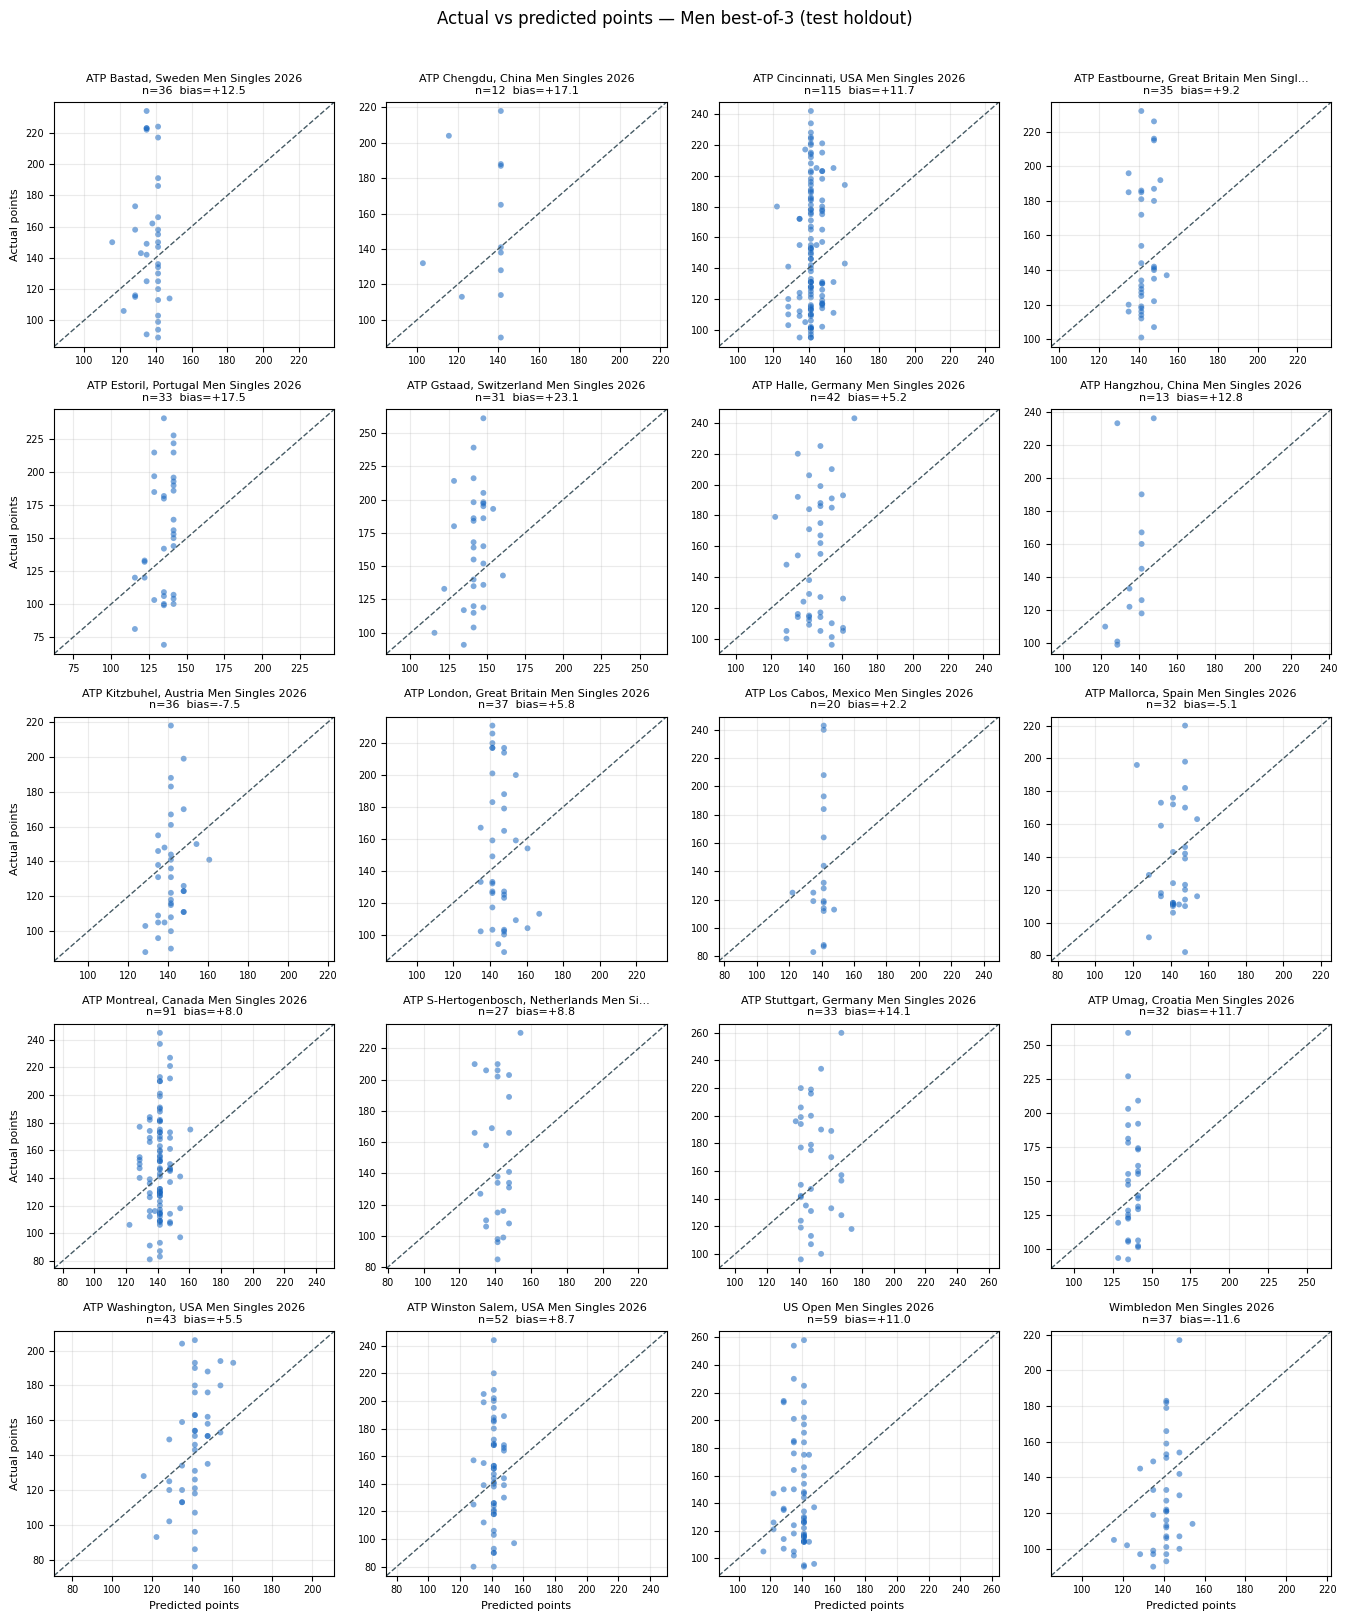

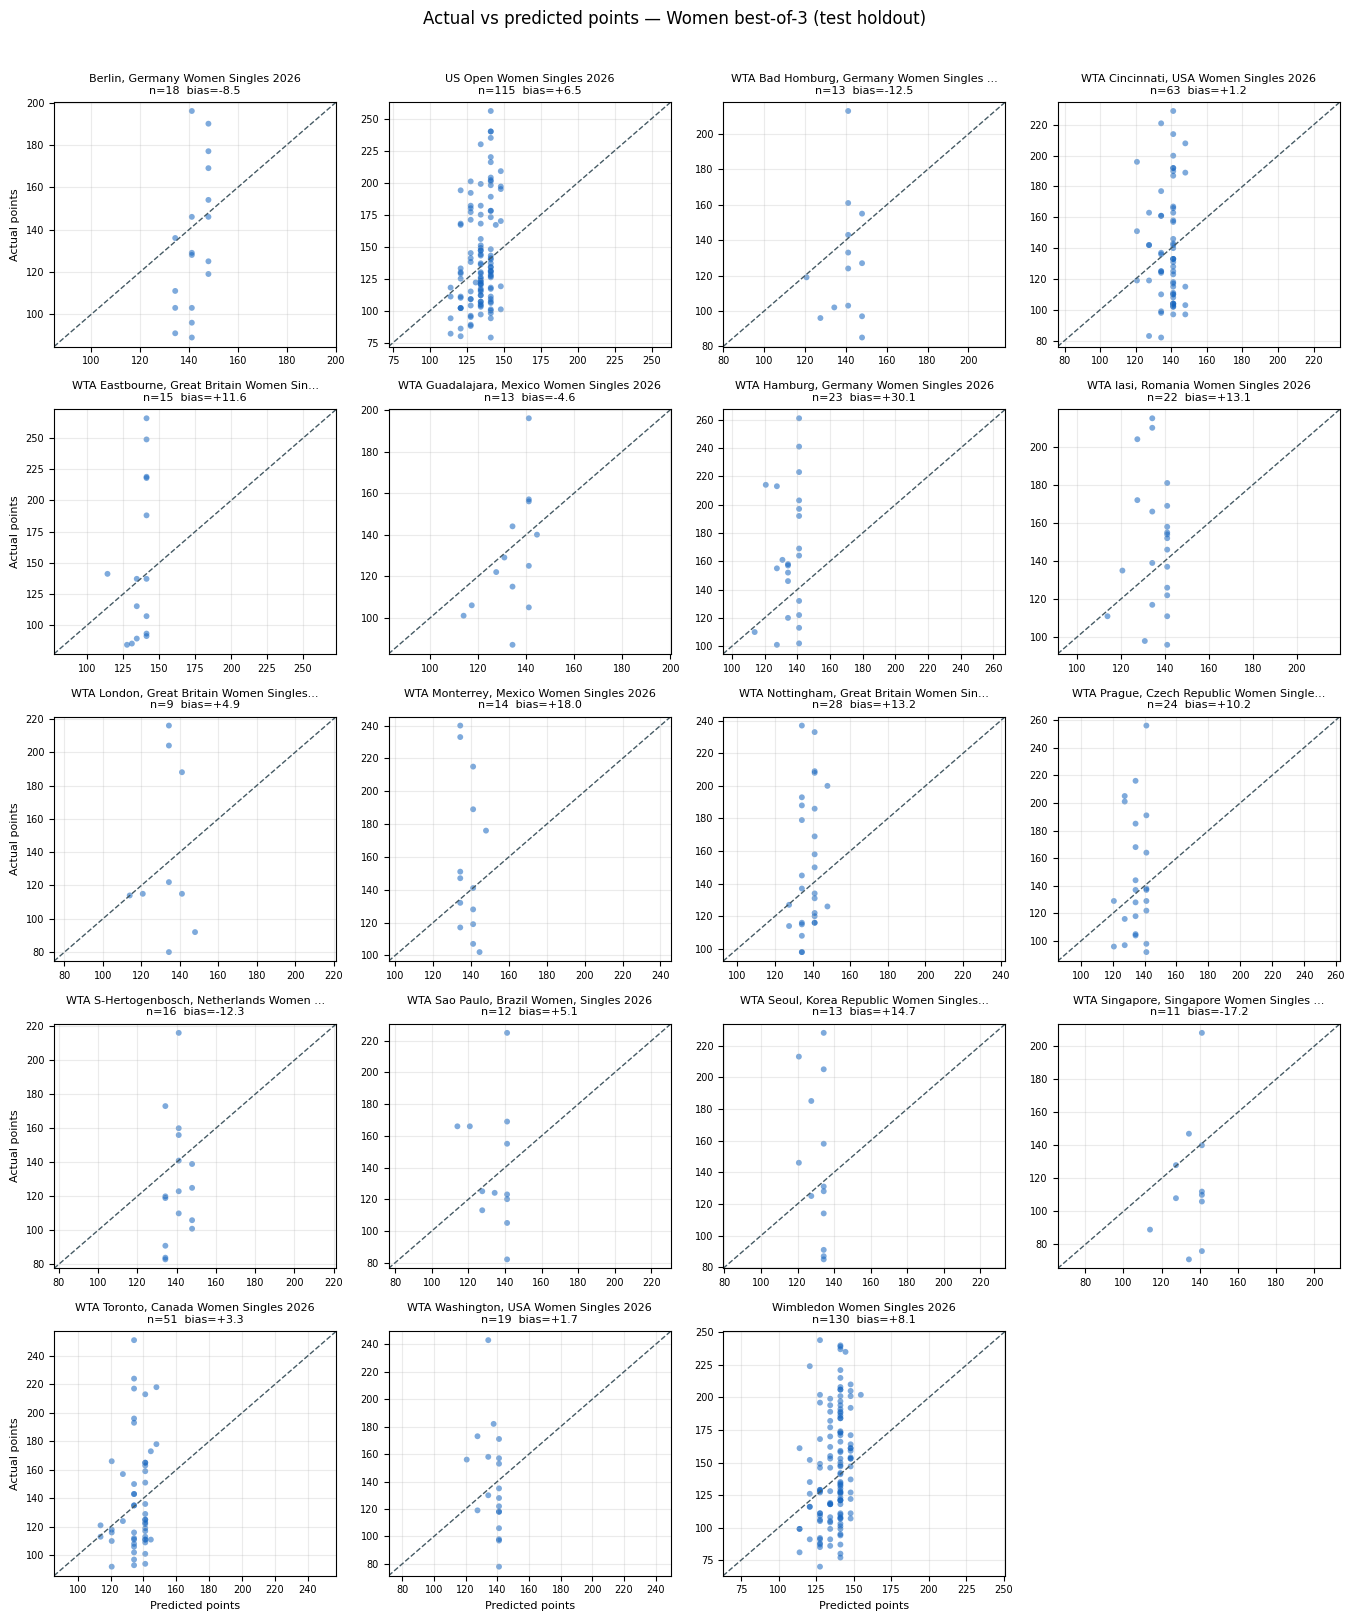

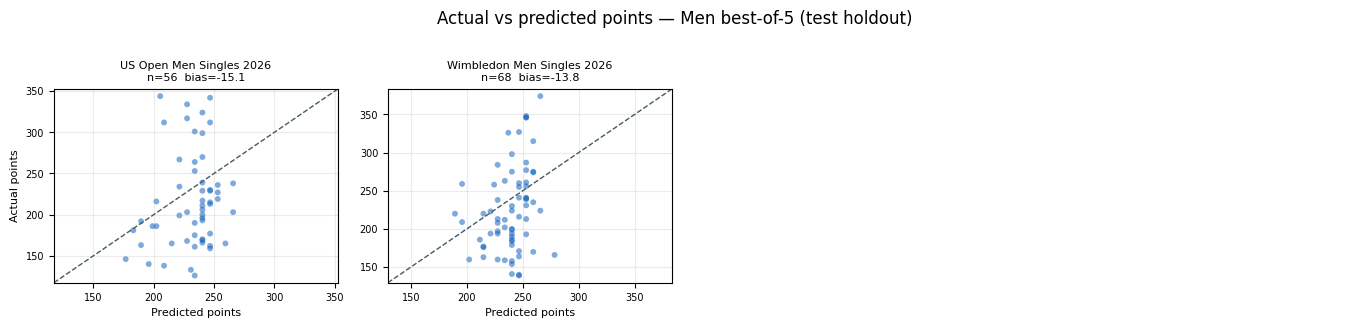

In [11]:
import math

gender_fits, scored_holdout = fit_and_score_gender_best_of(train_df, test_df)
print("Fits:", sorted(f"{g}_bo{bo}" for g, bo in gender_fits))
print(f"Scorable test matches: {len(scored_holdout):,}")

SEGMENT_SPECS = [
    ("men_bo3", "Men best-of-3"),
    ("women_bo3", "Women best-of-3"),
    ("men_bo5", "Men best-of-5"),
]

plot_base = scored_holdout.dropna(
    subset=["predicted_points", "total_points", "season_name", "season_id"]
).copy()
plot_base["season_name"] = plot_base["season_name"].astype(str)
plot_base["total_points"] = pd.to_numeric(plot_base["total_points"], errors="coerce")
plot_base["predicted_points"] = pd.to_numeric(plot_base["predicted_points"], errors="coerce")
plot_base = plot_base.dropna(subset=["total_points", "predicted_points"])
plot_base["residual"] = plot_base["total_points"] - plot_base["predicted_points"]

summary_rows = (
    plot_base.groupby(["model_segment", "season_id", "season_name"], dropna=False)
    .agg(
        n=("total_points", "size"),
        mean_actual=("total_points", "mean"),
        mean_pred=("predicted_points", "mean"),
        mean_bias=("residual", "mean"),
    )
    .reset_index()
    .sort_values(["model_segment", "season_name"])
)
display(summary_rows)

N_COLS = 4
for segment_key, segment_title in SEGMENT_SPECS:
    seg = plot_base.loc[plot_base["model_segment"] == segment_key].copy()
    if seg.empty:
        print(f"{segment_title}: no scorable test matches")
        continue

    tournaments = (
        seg.groupby(["season_id", "season_name"], dropna=False)
        .size()
        .reset_index(name="n")
        .sort_values("season_name")
        .reset_index(drop=True)
    )
    n_tourn = len(tournaments)
    n_rows = int(math.ceil(n_tourn / N_COLS))
    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(3.4 * N_COLS, 3.2 * n_rows),
        squeeze=False,
    )
    fig.suptitle(
        f"Actual vs predicted points — {segment_title} (test holdout)",
        y=1.01,
    )

    for idx, trow in tournaments.iterrows():
        r, c = divmod(int(idx), N_COLS)
        ax = axes[r][c]
        t = seg.loc[seg["season_id"] == trow["season_id"]]
        x = t["predicted_points"].to_numpy(dtype=float)
        y = t["total_points"].to_numpy(dtype=float)
        ax.scatter(x, y, s=18, alpha=0.55, color="#1565c0", edgecolors="none")
        lo = float(min(x.min(), y.min()))
        hi = float(max(x.max(), y.max()))
        pad = 0.04 * (hi - lo) if hi > lo else 5.0
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#455a64", ls="--", lw=1.0)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        bias = float((y - x).mean())
        name = str(trow["season_name"])
        if len(name) > 42:
            name = name[:39] + "..."
        ax.set_title(f"{name}\nn={int(trow['n'])}  bias={bias:+.1f}", fontsize=8)
        ax.grid(alpha=0.25)
        if r == n_rows - 1:
            ax.set_xlabel("Predicted points", fontsize=8)
        if c == 0:
            ax.set_ylabel("Actual points", fontsize=8)
        ax.tick_params(labelsize=7)

    for idx in range(n_tourn, n_rows * N_COLS):
        r, c = divmod(idx, N_COLS)
        axes[r][c].set_axis_off()

    plt.tight_layout()
    plt.show()
